# Análise e Preparação de Datasets para Reconhecimento de Expressões Faciais

## 1. Introdução ao Pré-processamento de Imagens

Para garantir que os modelos de aprendizado de máquina operem de forma eficiente e justa, é fundamental pré-processar os dados. Este notebook aborda o pipeline de pré-processamento para reconhecimento de emoções faciais, incluindo:

- Carregamento dos dados
- Redimensionamento para 96×96 pixels 
- Conversão para escala de cinza
- Normalização dos valores dos pixels
- Balanceamento pelo número da maior classe (Oversampling)
- Separação em treino, teste, validação (estratificada);

**FER-2013**: contém 35.887 imagens de 48×48 pixels em tons de cinza, com 7 emoções: 'angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'.

**RAF-DB**: aproximadamente 5.000 imagens anotadas em condições naturais ("in the wild") com maior diversidade de expressões e características demográficas. Classes similares ao FER.

To Do:
- Coloca early stopping 3 ou 5 épocas
- ReduceLROnPlateau (mínimo global) antes do early stopping diminuí a learning rate Pacience=10
- Procurar artigos para sustentar escolhas
- K-fold 3 ao inves de só holdout para treinar/validar/testar com conjuntos diferente e tirar a média
- Salvamento das imagens em png

Done:
- 96x96

In [1]:
import os #acessar e manipular diretórios e arquivos do sistema
import cv2 # OpenCV para leitura e processamento de imagens
import numpy as np #manipulação de arrays
from tqdm import tqdm #barra de progresso para visualizar carregamento de imagens
from collections import Counter #conta elementos para saber o número de imagens por classe
from sklearn.model_selection import train_test_split #separa os dados em treino e teste
from sklearn.utils import shuffle #embaralha os dados e rótulos na mesma ordem
import matplotlib.pyplot as plt #gráficos
import random
from sklearn.preprocessing import LabelEncoder
import pandas as pd

## Carregamento e Pré-processamento das Imagens

Esta função percorre as pastas de um dataset, redimensiona todas as imagens para 100x100 pixels, converte para escala de cinza e normaliza os valores dos pixels entre 0 e 1.

In [2]:
def load_images_from_directory(dataset_path, image_size=(96, 96)):
    """
    Carrega imagens de um diretório organizado por subpastas (uma para cada classe).

    Parâmetros:
    - dataset_path: caminho para o diretório raiz do dataset.
    - image_size: tupla com o tamanho desejado das imagens (largura, altura).

    Retorna:
    - X: numpy array contendo as imagens processadas.
    - y: numpy array contendo os rótulos (nomes das classes).
    """
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Diretório não encontrado: {dataset_path}")

    X = []  # Lista para armazenar imagens.
    y = []  # Lista para armazenar os rótulos correspondentes.

    # Obtém lista das classes a partir do nome das subpastas.
    classes = sorted(os.listdir(dataset_path))

    # Itera sobre cada classe (subpasta).
    for label in classes:
        class_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(class_dir):
            continue  # Garante que seja mesmo uma pasta.

        # Itera sobre cada arquivo de imagem na subpasta.
        for filename in tqdm(os.listdir(class_dir), desc=f'Carregando {label}'):
            filepath = os.path.join(class_dir, filename)

            # Lê a imagem em escala de cinza.
            image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue  # Pula arquivos que não são imagens válidas.

            # Redimensiona a imagem para o tamanho padrão (100x100).
            image = cv2.resize(image, image_size)

            # Normaliza os pixels para o intervalo [0, 1].
            image = image / 255.0

            # Armazena a imagem e seu respectivo rótulo.
            X.append(image)
            y.append(label)

    # Converte as listas para arrays numpy.
    return np.array(X), np.array(y)


## Separação em treino, validação e teste:

Neste passo, realizamos a divisão do conjunto de dados em três partes:

- 80% dos dados para treinamento e validação;
- 20% para teste final.

Em seguida, do conjunto de treinamento, separamos 10% para o conjunto de validação, que será usado para ajuste fino e evitar overfitting.

A estratificação é usada em todas as divisões, garantindo que a proporção das classes seja mantida.


In [3]:
def split_train_val_test(X, y, test_size=0.2, val_split=0.1, random_state=42):
    """
    Divide os dados em treino, validação e teste, com estratificação.
    
    Parâmetros:
    - X: array de imagens.
    - y: array de rótulos.
    - test_size: fração do conjunto reservado para teste (default = 20%).
    - val_split: fração da parte de treino que será reservada para validação (default = 10%).
    - random_state: para reprodutibilidade.
    
    Retorna:
    - X_train, X_val, X_test: arrays com imagens.
    - y_train, y_val, y_test: arrays com rótulos.
    """

    # Primeira divisão: treino e teste
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # Calcula a fração de validação em relação ao conjunto de treino
    val_size = val_split / (1 - test_size)  # Ajuste proporcional ao novo conjunto de treino

    # Segunda divisão: separa parte da validação do treino
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=val_size,
        stratify=y_train_full,
        random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

## Balanceamento do Conjunto de Treinamento por Subamostragem

O balanceamento é essencial para evitar que o modelo aprenda a favorecer classes majoritárias, prejudicando a performance nas classes minoritárias.

Aqui, realizamos subamostragem com base na classe menos representada no conjunto de dados, reduzindo o número de exemplos das classes maiores para igualar ao da menor.

Essa estratégia é aplicada apenas no conjunto de treino, evitando viés na validação e teste.

Após a subamostragem, os dados são embaralhados para garantir aleatoriedade.


In [4]:
def balance_by_min_class(X, y):
    """
    Realiza subamostragem para balancear as classes com base na menor classe presente no dataset.

    Parâmetros:
    - X: array de imagens.
    - y: array de rótulos.

    Retorna:
    - X_bal: conjunto de imagens balanceado.
    - y_bal: rótulos balanceados.
    """
    class_counts = Counter(y)
    min_class = min(class_counts.values())

    print(f"Classes encontradas: {class_counts}")
    print(f"Tamanho da menor classe: {min_class}")

    X_bal = []
    y_bal = []

    for emotion in class_counts.keys():
        idxs = np.where(y == emotion)[0]

        # Apenas seleciona se houverem exemplos suficientes
        if len(idxs) >= min_class:
            selected_idxs = np.random.choice(idxs, min_class, replace=False)
        else:
            print(f"Aviso: classe '{emotion}' com menos exemplos que o mínimo. Pulando.")
            continue

        X_bal.append(X[selected_idxs])
        y_bal.append(y[selected_idxs])

    # Concatena os arrays
    X_bal = np.concatenate(X_bal, axis=0)
    y_bal = np.concatenate(y_bal, axis=0)

    # Embaralha o conjunto
    indices = np.arange(len(X_bal))
    np.random.shuffle(indices)

    return X_bal[indices], y_bal[indices]


## Ajuste de Formato para CNN

As redes neurais convolucionais (CNNs) geralmente esperam as imagens com um formato específico: (amostras, altura, largura, canais).

Como nossas imagens foram carregadas em escala de cinza, elas possuem apenas duas dimensões: altura e largura.

Esta função adiciona uma dimensão extra para representar o canal da imagem, que no caso é 1 (para imagens em tons de cinza).

Assim, o formato das imagens passa de (n_amostras, 100, 100) para (n_amostras, 100, 100, 1), ficando compatível com a entrada esperada pela maioria das CNNs implementadas no TensorFlow ou PyTorch.

In [5]:
def prepare_for_cnn(X):
    """
    Prepara as imagens para entrada na CNN, adicionando uma dimensão de canal.

    Parâmetro:
    - X: array de imagens, com formato (n_amostras, altura, largura).

    Retorna:
    - X preparado: array com formato (n_amostras, altura, largura, 1).
    """
    return np.expand_dims(X, axis=-1)  # Adiciona dimensão do canal

## Salvando os Datasets Pré-processados

Após o pré-processamento e a separação em conjuntos de treino e teste, é uma boa prática salvar os dados em arquivos compactados.

Assim, não precisamos repetir o pré-processamento toda vez que formos treinar ou avaliar modelos.

A função abaixo usa o formato .npz, que é compacto e eficiente para armazenar múltiplos arrays.

Cada dataset pode ser salvo com um prefixo que identifica qual base de dados foi processada, como 'fer2013', 'rafdb' ou qualquer outro nome.


In [6]:
def save_preprocessed_data(X_train, y_train, 
                           X_val, y_val, 
                           X_test, y_test, 
                           output_dir='datasets_preprocessed', 
                           prefix='dataset'):
    """
    Salva os conjuntos de dados pré-processados em arquivos:
    - Formato .npz (compactado)
    - Formato .csv (tabular)

    Parâmetros:
    - X_train, y_train, X_val, y_val, X_test, y_test: arrays numpy dos dados.
    - output_dir: pasta de destino.
    - prefix: prefixo para nomear os arquivos.
    """

    # Cria a pasta se não existir
    os.makedirs(output_dir, exist_ok=True)

    # Lista de conjuntos
    datasets = {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test)
    }

    for split_name, (X_split, y_split) in datasets.items():
        # Caminhos
        npz_path = os.path.join(output_dir, f'{prefix}_{split_name}.npz')
        csv_path = os.path.join(output_dir, f'{prefix}_{split_name}.csv')

        # Salva .npz
        np.savez_compressed(npz_path, X=X_split, y=y_split)

        # Converte para DataFrame: 
        # achatando a imagem para uma linha de pixels.
        X_flat = X_split.reshape((X_split.shape[0], -1))
        df = pd.DataFrame(X_flat)
        df['label'] = y_split  # adiciona coluna de rótulo

        # Salva .csv
        df.to_csv(csv_path, index=False)

        # Mensagem de sucesso
        print(f'Arquivos salvos para {split_name} em:')
        print(f'   - {npz_path}')
        print(f'   - {csv_path}')


## Aplicação do Pipeline em um Dataset

Aqui aplicamos todas as etapas acima em um dataset. O caminho deve apontar para a pasta onde estão os diretórios com as emoções.


In [7]:
# Caminho para o dataset 
dataset_name = 'RAF-DB'
dataset_path = f'../../datasets/{dataset_name}/DATASET/brutos'

# Etapa 1: Carregar as imagens
print("Carregando imagens...")
X, y = load_images_from_directory(dataset_path)
print(f"Total de imagens carregadas: {len(X)}")

# Etapa 2: Dividir o dataset
print("Realizando divisão em treino, validação e teste...")
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y)

print(f" - Treino: {len(X_train)} imagens")
print(f" - Validação: {len(X_val)} imagens")
print(f" - Teste: {len(X_test)} imagens")

# Etapa 3: Subamostragem apenas no treino
print("Realizando subamostragem no conjunto de treino para balanceamento...")
X_train_bal, y_train_bal = balance_by_min_class(X_train, y_train)
print(f" - Tamanho original do treino: {len(X_train)}")
print(f" - Tamanho balanceado do treino: {len(X_train_bal)}")

# Etapa 4: Preparar para CNN
print("Preparando dados para a CNN...")
X_train_bal = prepare_for_cnn(X_train_bal)
X_val = prepare_for_cnn(X_val)
X_test = prepare_for_cnn(X_test)
print(" - Formato das imagens de treino balanceado:", X_train_bal.shape)
print(" - Formato das imagens de validação:", X_val.shape)
print(" - Formato das imagens de teste:", X_test.shape)


Carregando imagens...


Carregando surprise: 100%|██████████| 1619/1619 [00:01<00:00, 1036.88it/s]


Total de imagens carregadas: 15339
Realizando divisão em treino, validação e teste...
 - Treino: 10737 imagens
 - Validação: 1534 imagens
 - Teste: 3068 imagens
Realizando subamostragem no conjunto de treino para balanceamento...
Classes encontradas: Counter({'happy': 4169, 'neutral': 2243, 'sadness': 1722, 'surprise': 1133, 'disgust': 614, 'anger': 607, 'fear': 249})
Tamanho da menor classe: 249
 - Tamanho original do treino: 10737
 - Tamanho balanceado do treino: 1743
Preparando dados para a CNN...
 - Formato das imagens de treino balanceado: (1743, 96, 96, 1)
 - Formato das imagens de validação: (1534, 96, 96, 1)
 - Formato das imagens de teste: (3068, 96, 96, 1)


## Exemplo de imagens pré-processadas

Nesta etapa, vamos visualizar algumas imagens do conjunto de treino balanceado, organizadas por classe.

Isso é útil para:

- verificar se o pré-processamento (redimensionamento, normalização) foi feito corretamente;
- verificar o equilíbrio entre as classes após a subamostragem.

Cada linha da grade corresponde a uma classe, com algumas imagens exemplo.

Exibindo amostras do conjunto de treino balanceado...


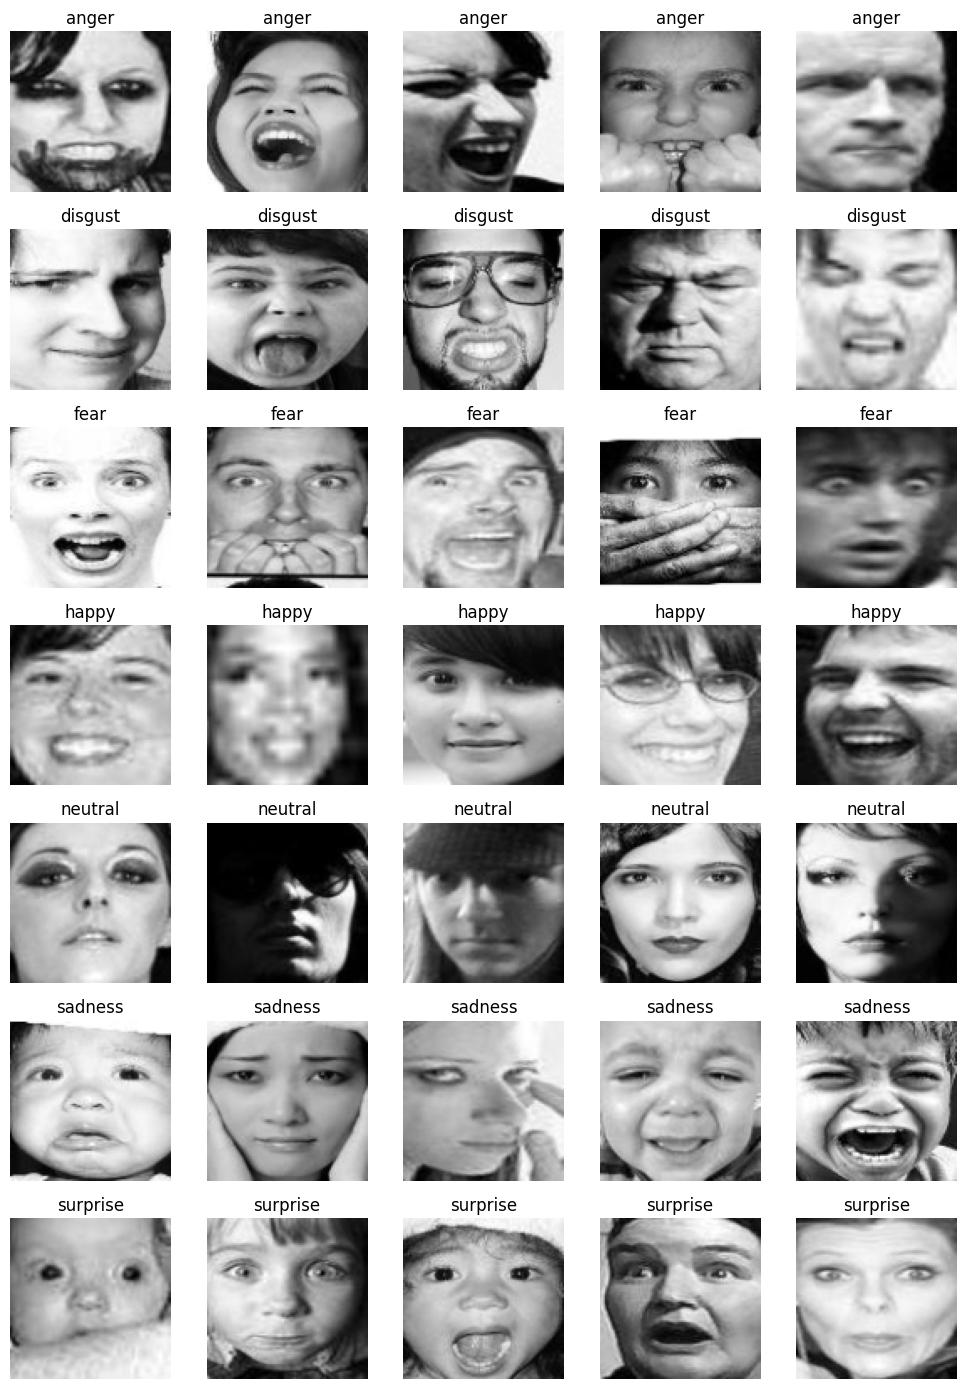

In [8]:
# Primeiro, codifique os rótulos para inteiros, se ainda não fez:
label_encoder = LabelEncoder()
y_train_bal_enc = label_encoder.fit_transform(y_train_bal)

# Agora podemos definir a função:

def show_sample_images(images, labels, class_names, samples_per_class=5):
    """
    Exibe uma grade com amostras aleatórias por classe, após o pré-processamento.

    Parâmetros:
    - images: array com as imagens pré-processadas (N x H x W x 1)
    - labels: array com rótulos inteiros
    - class_names: lista de nomes das classes (str)
    - samples_per_class: quantas imagens mostrar por classe
    """
    num_classes = len(class_names)
    plt.figure(figsize=(samples_per_class * 2, num_classes * 2))

    for class_idx, class_name in enumerate(class_names):
        # Indices de todas as imagens dessa classe
        idxs = [i for i, label in enumerate(labels) if label == class_idx]
        selected = random.sample(idxs, min(samples_per_class, len(idxs)))

        for i, idx in enumerate(selected):
            plt_idx = class_idx * samples_per_class + i + 1
            plt.subplot(num_classes, samples_per_class, plt_idx)
            image = images[idx].squeeze()  # remove o canal se for 1

            plt.imshow(image, cmap='gray')
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Etapa 5: Visualizar amostras do dataset
print("Exibindo amostras do conjunto de treino balanceado...")

# Exemplo de uso:
class_names = list(label_encoder.classes_)  # nomes das classes

show_sample_images(X_train_bal, y_train_bal_enc, class_names)


In [9]:
"""# Etapa 6: Salvar conjuntos de dados
print("Salvando os conjuntos de dados pré-processados...")
# Salva os conjuntos balanceados e processados
save_preprocessed_data(X_train_bal, y_train_bal, 
                       X_val, y_val, 
                       X_test, y_test, 
                       output_dir='datasets_final', 
                       prefix= dataset_name)

print("\nPipeline de pré-processamento concluído com sucesso!")
"""

'# Etapa 6: Salvar conjuntos de dados\nprint("Salvando os conjuntos de dados pré-processados...")\n# Salva os conjuntos balanceados e processados\nsave_preprocessed_data(X_train_bal, y_train_bal, \n                       X_val, y_val, \n                       X_test, y_test, \n                       output_dir=\'datasets_final\', \n                       prefix= dataset_name)\n\nprint("\nPipeline de pré-processamento concluído com sucesso!")\n'

In [10]:
def save_images_by_emotion(X_train, y_train, X_test, y_test, 
                          output_dir='dataset_organized', 
                          prefix='dataset',
                          image_format='jpg'):
    """
    Salva as imagens organizadas em estrutura de pastas:
    output_dir/
    ├── train/
    │   ├── angry/
    │   ├── disgust/
    │   ├── fear/
    │   ├── happy/
    │   ├── sad/
    │   ├── surprise/
    │   └── neutral/
    └── test/
        ├── angry/
        ├── disgust/
        ├── fear/
        ├── happy/
        ├── sad/
        ├── surprise/
        └── neutral/

    Parâmetros:
    - X_train, y_train: dados de treino (imagens e rótulos)
    - X_test, y_test: dados de teste (imagens e rótulos)
    - output_dir: diretório de saída
    - prefix: prefixo para nomear as imagens
    - image_format: formato das imagens ('jpg', 'png', 'bmp', 'tiff')
    """
    
    # Mapeamento para normalizar nomes das emoções
    emotion_mapping = {
        'anger': 'angry',
        'angry': 'angry',
        'disgust': 'disgust',
        'fear': 'fear',
        'happiness': 'happy',
        'happy': 'happy',
        'sadness': 'sad',
        'sad': 'sad',
        'surprise': 'surprise',
        'neutral': 'neutral'
    }
    
    # Verificar quais emoções únicas temos
    unique_emotions_train = set(y_train)
    unique_emotions_test = set(y_test)
    all_emotions = unique_emotions_train.union(unique_emotions_test)
    
    print(f"Emoções encontradas: {all_emotions}")
    
    # Cria estrutura de diretórios baseada nas emoções mapeadas
    mapped_emotions = set()
    for emotion in all_emotions:
        mapped_emotion = emotion_mapping.get(emotion, emotion)
        mapped_emotions.add(mapped_emotion)
    
    for split in ['train', 'test']:
        for emotion in mapped_emotions:
            emotion_dir = os.path.join(output_dir, split, emotion)
            os.makedirs(emotion_dir, exist_ok=True)
    
    print(f"Estrutura de diretórios criada em: {output_dir}")
    print(f"Emoções mapeadas: {mapped_emotions}")
    
    # Função auxiliar para salvar um conjunto
    def save_split(X, y, split_name):
        print(f"\nSalvando conjunto de {split_name}...")
        print(f"Formato das imagens: {X.shape}")
        print(f"Tipo de dados das imagens: {X.dtype}")
        print(f"Range de valores: min={X.min():.3f}, max={X.max():.3f}")
        
        # Contadores para nomear as imagens
        emotion_counters = Counter()
        total_saved = 0
        total_errors = 0
        
        for i, (image, label) in enumerate(zip(X, y)):
            try:
                # Remove a dimensão extra se existir (de CNN)
                if len(image.shape) == 3 and image.shape[2] == 1:
                    image = image.squeeze(axis=2)
                
                # Garantir que a imagem está no formato correto
                if image.dtype != np.uint8:
                    if image.max() <= 1.0:
                        # Imagem normalizada [0,1] -> converter para [0,255]
                        image = (image * 255.0).astype(np.uint8)
                    else:
                        # Imagem já em escala [0,255] mas tipo errado
                        image = np.clip(image, 0, 255).astype(np.uint8)
                
                # Mapear o nome da emoção
                emotion_name = emotion_mapping.get(label, label)
                
                # Nome do arquivo
                emotion_counters[emotion_name] += 1
                filename = f"{prefix}_{emotion_name}_{emotion_counters[emotion_name]:05d}.{image_format}"
                
                # Caminho completo
                filepath = os.path.join(output_dir, split_name, emotion_name, filename)
                
                # Salva a imagem
                success = cv2.imwrite(filepath, image)
                
                if success:
                    total_saved += 1
                    if total_saved % 100 == 0:  # Mostra progresso a cada 100 imagens
                        print(f"  Salvas: {total_saved} imagens...")
                else:
                    total_errors += 1
                    if total_errors <= 10:  # Mostrar apenas os primeiros 10 erros
                        print(f"Erro ao salvar: {filepath}")
                        print(f"  - Shape: {image.shape}, dtype: {image.dtype}")
                        print(f"  - Min: {image.min()}, Max: {image.max()}")
                    
            except Exception as e:
                total_errors += 1
                if total_errors <= 10:
                    print(f"Exceção ao processar imagem {i}: {e}")
        
        # Mostra estatísticas finais
        print(f"\nResultados para {split_name}:")
        print(f"  - Total salvas: {total_saved}")
        print(f"  - Total erros: {total_errors}")
        print(f"  - Distribuição por emoção:")
        for emotion, count in emotion_counters.items():
            print(f"    * {emotion}: {count} imagens")
    
    # Salva treino e teste
    save_split(X_train, y_train, 'train')
    save_split(X_test, y_test, 'test')
    
    print(f"\nDataset organizado salvo em: {output_dir}")

In [11]:

print("Organizando e salvando imagens por emoções...")

# Debug: verificar os tipos e formatos dos dados
print(f"Formato X_train_bal: {X_train_bal.shape}, dtype: {X_train_bal.dtype}")
print(f"Formato X_test: {X_test.shape}, dtype: {X_test.dtype}")
print(f"Exemplos de rótulos de treino: {y_train_bal[:5]}")
print(f"Exemplos de rótulos de teste: {y_test[:5]}")

# Preparar os rótulos
if isinstance(y_train_bal[0], (int, np.integer)):
    print("Convertendo rótulos numéricos de treino para nomes...")
    y_train_names = label_encoder.inverse_transform(y_train_bal_enc)
else:
    y_train_names = y_train_bal

if isinstance(y_test[0], (int, np.integer)):
    print("Convertendo rótulos numéricos de teste para nomes...")
    y_test_enc = label_encoder.transform(y_test)
    y_test_names = label_encoder.inverse_transform(y_test_enc)
else:
    y_test_names = y_test

# Salva as imagens organizadas por emoção
save_images_by_emotion(X_train_bal, y_train_names, 
                      X_test, y_test_names,
                      output_dir=f'{dataset_name}_organized', 
                      prefix=dataset_name,
                      image_format='jpg')  # Mudando para JPG que é mais compatível

print("\nPipeline de pré-processamento e organização concluído com sucesso!")

Organizando e salvando imagens por emoções...
Formato X_train_bal: (1743, 96, 96, 1), dtype: float64
Formato X_test: (3068, 96, 96, 1), dtype: float64
Exemplos de rótulos de treino: ['surprise' 'disgust' 'disgust' 'neutral' 'anger']
Exemplos de rótulos de teste: ['sadness' 'anger' 'surprise' 'sadness' 'neutral']
Emoções encontradas: {'surprise', 'disgust', 'neutral', 'fear', 'sadness', 'happy', 'anger'}
Estrutura de diretórios criada em: RAF-DB_organized
Emoções mapeadas: {'surprise', 'disgust', 'angry', 'neutral', 'sad', 'fear', 'happy'}

Salvando conjunto de train...
Formato das imagens: (1743, 96, 96, 1)
Tipo de dados das imagens: float64
Range de valores: min=0.000, max=1.000
  Salvas: 100 imagens...
  Salvas: 200 imagens...
  Salvas: 300 imagens...
  Salvas: 400 imagens...
  Salvas: 500 imagens...
  Salvas: 600 imagens...
  Salvas: 700 imagens...
  Salvas: 800 imagens...
  Salvas: 900 imagens...
  Salvas: 1000 imagens...
  Salvas: 1100 imagens...
  Salvas: 1200 imagens...
  Salvas